In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

print("Libraries loaded successfully")

Libraries loaded successfully


In [3]:
# Load main application table
app_train = pd.read_csv('data/application_train.csv')

print(f"Rows: {app_train.shape[0]:,}")
print(f"Columns: {app_train.shape[1]}")
print(f"\nTarget distribution:")
print(app_train['TARGET'].value_counts())
print(f"\nDefault rate: {app_train['TARGET'].mean() * 100:.2f}%")

Rows: 307,511
Columns: 122

Target distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Default rate: 8.07%


In [4]:
# First look at structure
print("=== DATA TYPES & NULL COUNTS ===")
print(app_train.dtypes.value_counts())

print(f"\n=== SAMPLE OF FIRST 5 ROWS ===")
app_train.head()

=== DATA TYPES & NULL COUNTS ===
float64    65
int64      41
object     16
Name: count, dtype: int64

=== SAMPLE OF FIRST 5 ROWS ===


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,...,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.000,406597.500,24700.500,351000.000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.019,-9461,-637,-3648.000,-2120,NaN,1,1,0,1,1,0,Laborers,1.000,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083,0.263,0.139,0.025,0.037,0.972,0.619,0.014,0.000,...,0.025,0.037,0.972,0.624,0.014,0.000,0.069,0.083,0.125,0.037,0.021,0.019,0.000,0.000,reg oper account,block of flats,0.015,"Stone, brick",No,2.000,2.000,2.000,2.000,-1134.000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000,0.000,0.000,0.000,0.000,1.000
1,100003,0,Cash loans,F,N,N,0,270000.000,1293502.500,35698.500,1129500.000,Family,State servant,Higher education,Married,House / apartment,0.004,-16765,-1188,-1186.000,-291,NaN,1,1,0,1,1,0,Core staff,2.000,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311,0.622,NaN,0.096,0.053,0.985,0.796,0.060,0.080,...,0.097,0.053,0.985,0.799,0.061,0.080,0.035,0.292,0.333,0.013,0.079,0.056,0.004,0.010,reg oper account,block of flats,0.071,Block,No,1.000,0.000,1.000,0.000,-828.000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000
2,100004,0,Revolving loans,M,Y,Y,0,67500.000,135000.000,6750.000,135000.000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010,-19046,-225,-4260.000,-2531,26.000,1,1,1,1,1,0,Laborers,1.000,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.556,0.730,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,0.000,0.000,0.000,-815.000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000
3,100006,0,Cash loans,F,N,Y,0,135000.000,312682.500,29686.500,297000.000,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.008,-19005,-3039,-9833.000,-2437,NaN,1,1,0,1,0,0,Laborers,2.000,2,2,WEDNESDAY,17,0,0,0,0,0,0,Business Entity Type 3,NaN,0.650,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000,0.000,2.000,0.000,-617.000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.000,513000.000,21865.500,513

In [5]:
# Missing value analysis
missing = app_train.isnull().sum()
missing_pct = (missing / len(app_train)) * 100

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).sort_values('missing_pct', ascending=False)

# Only show columns that actually have missing values
missing_df = missing_df[missing_df['missing_count'] > 0]

print(f"Columns with missing values: {len(missing_df)} out of {app_train.shape[1]}")
print(f"\nTop 20 columns by missing %:")
print(missing_df.head(20).to_string())

Columns with missing values: 67 out of 122

Top 20 columns by missing %:
                          missing_count  missing_pct
COMMONAREA_AVG                   214865       69.872
COMMONAREA_MODE                  214865       69.872
COMMONAREA_MEDI                  214865       69.872
NONLIVINGAPARTMENTS_MEDI         213514       69.433
NONLIVINGAPARTMENTS_MODE         213514       69.433
NONLIVINGAPARTMENTS_AVG          213514       69.433
FONDKAPREMONT_MODE               210295       68.386
LIVINGAPARTMENTS_AVG             210199       68.355
LIVINGAPARTMENTS_MEDI            210199       68.355
LIVINGAPARTMENTS_MODE            210199       68.355
FLOORSMIN_MODE                   208642       67.849
FLOORSMIN_AVG                    208642       67.849
FLOORSMIN_MEDI                   208642       67.849
YEARS_BUILD_AVG                  204488       66.498
YEARS_BUILD_MODE                 204488       66.498
YEARS_BUILD_MEDI                 204488       66.498
OWN_CAR_AGE               

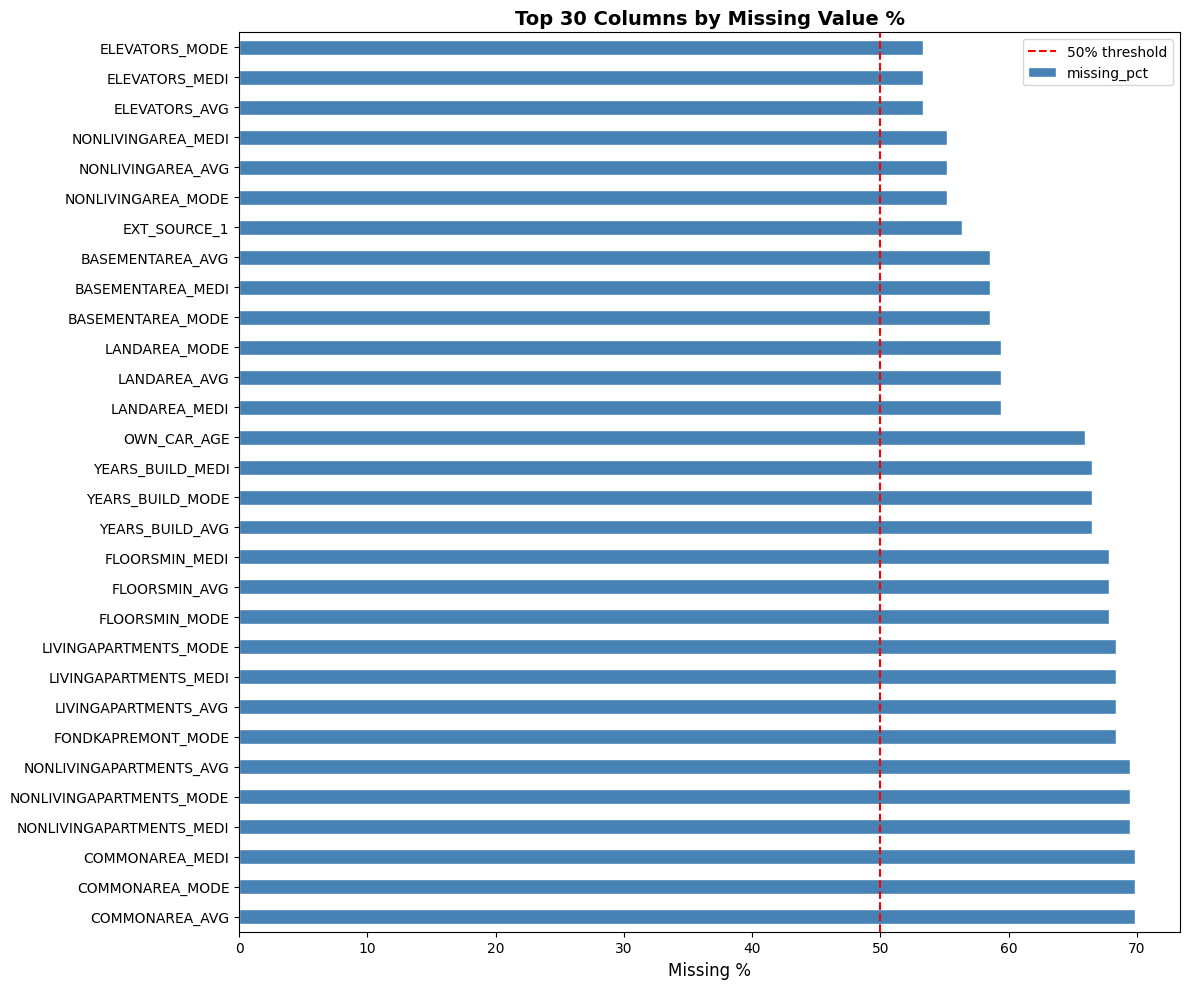

Plot saved to reports/missing_values.png


In [6]:
# Visualise top 30 missing columns
plt.figure(figsize=(12, 10))
missing_df.head(30)['missing_pct'].plot(kind='barh', color='steelblue', edgecolor='white')
plt.xlabel('Missing %', fontsize=12)
plt.title('Top 30 Columns by Missing Value %', fontsize=14, fontweight='bold')
plt.axvline(x=50, color='red', linestyle='--', linewidth=1.5, label='50% threshold')
plt.legend()
plt.tight_layout()
plt.savefig('reports/missing_values.png', dpi=150)
plt.show()

print("Plot saved to reports/missing_values.png")

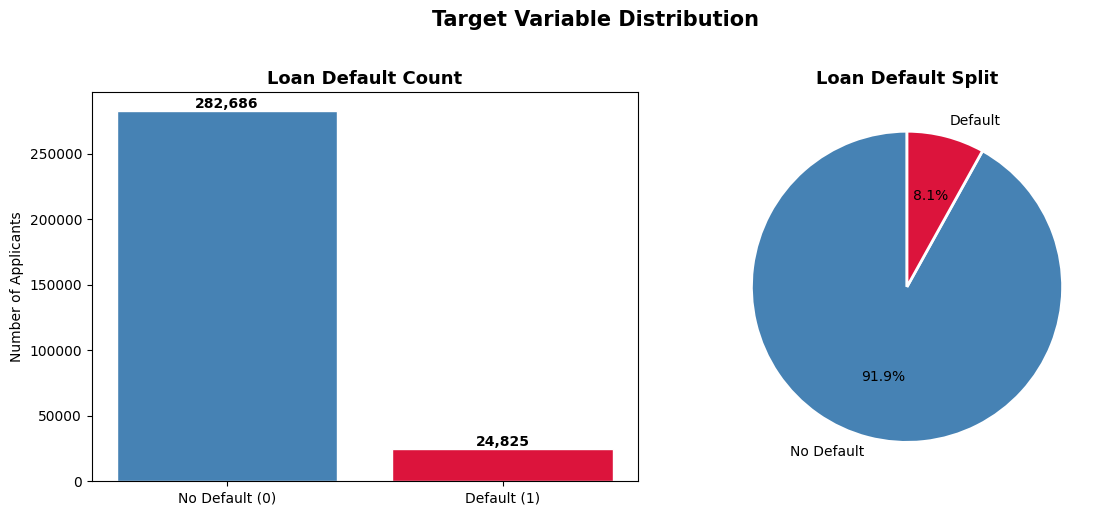

Visualisation 2 saved.


In [7]:
# Visualisation 2: Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
axes[0].bar(['No Default (0)', 'Default (1)'], 
            app_train['TARGET'].value_counts().values,
            color=['steelblue', 'crimson'], edgecolor='white')
axes[0].set_title('Loan Default Count', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Applicants')
for i, v in enumerate(app_train['TARGET'].value_counts().values):
    axes[0].text(i, v + 2000, f'{v:,}', ha='center', fontweight='bold')

# Percentage plot
axes[1].pie(app_train['TARGET'].value_counts().values,
            labels=['No Default', 'Default'],
            colors=['steelblue', 'crimson'],
            autopct='%1.1f%%',
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Loan Default Split', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('reports/target_distribution.png', dpi=150)
plt.show()

print("Visualisation 2 saved.")

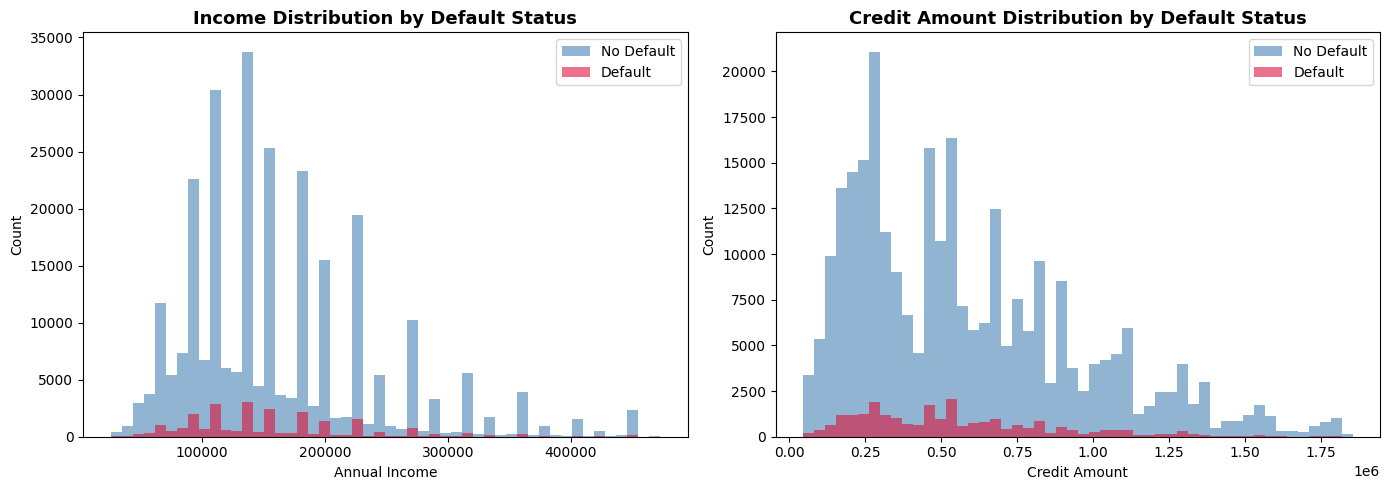

Visualisations 3 & 4 saved.


In [8]:
# Visualisation 3: Income distribution by target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Remove extreme outliers for cleaner visualisation (top 1%)
income_cap = app_train['AMT_INCOME_TOTAL'].quantile(0.99)
income_data = app_train[app_train['AMT_INCOME_TOTAL'] <= income_cap]

# Distribution by target
for target, label, color in [(0, 'No Default', 'steelblue'), (1, 'Default', 'crimson')]:
    subset = income_data[income_data['TARGET'] == target]['AMT_INCOME_TOTAL']
    axes[0].hist(subset, bins=50, alpha=0.6, label=label, color=color, edgecolor='none')

axes[0].set_title('Income Distribution by Default Status', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Annual Income')
axes[0].set_ylabel('Count')
axes[0].legend()

# Visualisation 4: Credit amount distribution by target
credit_cap = app_train['AMT_CREDIT'].quantile(0.99)
credit_data = app_train[app_train['AMT_CREDIT'] <= credit_cap]

for target, label, color in [(0, 'No Default', 'steelblue'), (1, 'Default', 'crimson')]:
    subset = credit_data[credit_data['TARGET'] == target]['AMT_CREDIT']
    axes[1].hist(subset, bins=50, alpha=0.6, label=label, color=color, edgecolor='none')

axes[1].set_title('Credit Amount Distribution by Default Status', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Credit Amount')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('reports/income_credit_distribution.png', dpi=150)
plt.show()

print("Visualisations 3 & 4 saved.")

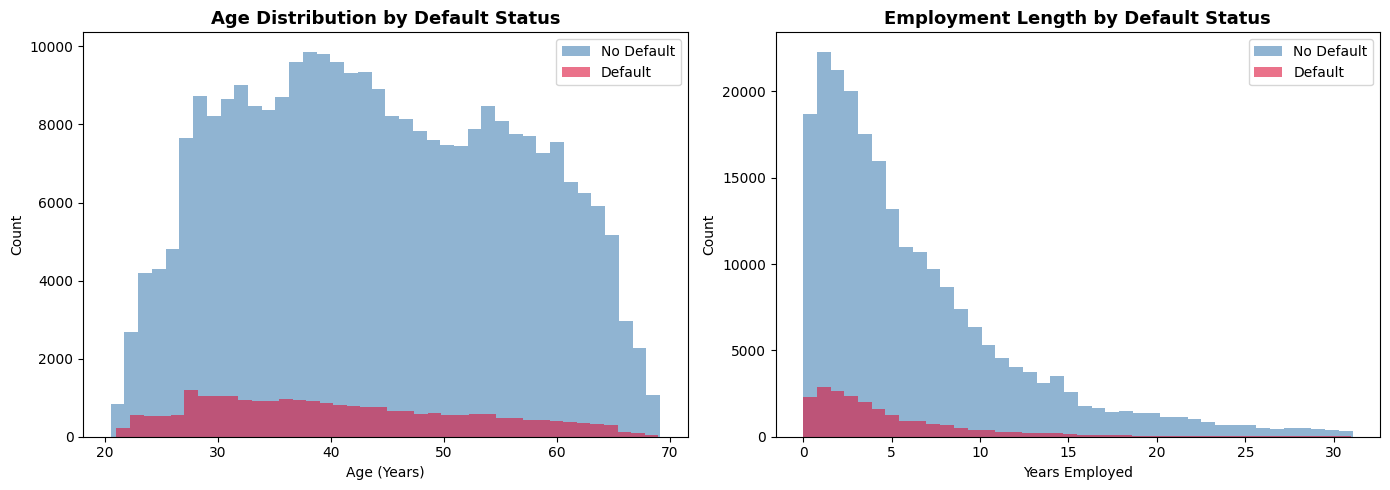

Applicants with DAYS_EMPLOYED anomaly (365243): 55,374
Visualisations 5 & 6 saved.


In [9]:
# Visualisation 5: Age distribution by target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# DAYS_BIRTH is negative (days before application) — convert to years
app_train['AGE_YEARS'] = abs(app_train['DAYS_BIRTH']) / 365

for target, label, color in [(0, 'No Default', 'steelblue'), (1, 'Default', 'crimson')]:
    subset = app_train[app_train['TARGET'] == target]['AGE_YEARS']
    axes[0].hist(subset, bins=40, alpha=0.6, label=label, color=color, edgecolor='none')

axes[0].set_title('Age Distribution by Default Status', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age (Years)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Visualisation 6: Employment length by target
# DAYS_EMPLOYED has a known anomaly — 365243 means pensioner/unemployed
emp_data = app_train[app_train['DAYS_EMPLOYED'] != 365243].copy()
emp_data['EMPLOYMENT_YEARS'] = abs(emp_data['DAYS_EMPLOYED']) / 365

emp_cap = emp_data['EMPLOYMENT_YEARS'].quantile(0.99)
emp_data = emp_data[emp_data['EMPLOYMENT_YEARS'] <= emp_cap]

for target, label, color in [(0, 'No Default', 'steelblue'), (1, 'Default', 'crimson')]:
    subset = emp_data[emp_data['TARGET'] == target]['EMPLOYMENT_YEARS']
    axes[1].hist(subset, bins=40, alpha=0.6, label=label, color=color, edgecolor='none')

axes[1].set_title('Employment Length by Default Status', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Years Employed')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('reports/age_employment_distribution.png', dpi=150)
plt.show()

print(f"Applicants with DAYS_EMPLOYED anomaly (365243): {(app_train['DAYS_EMPLOYED'] == 365243).sum():,}")
print("Visualisations 5 & 6 saved.")

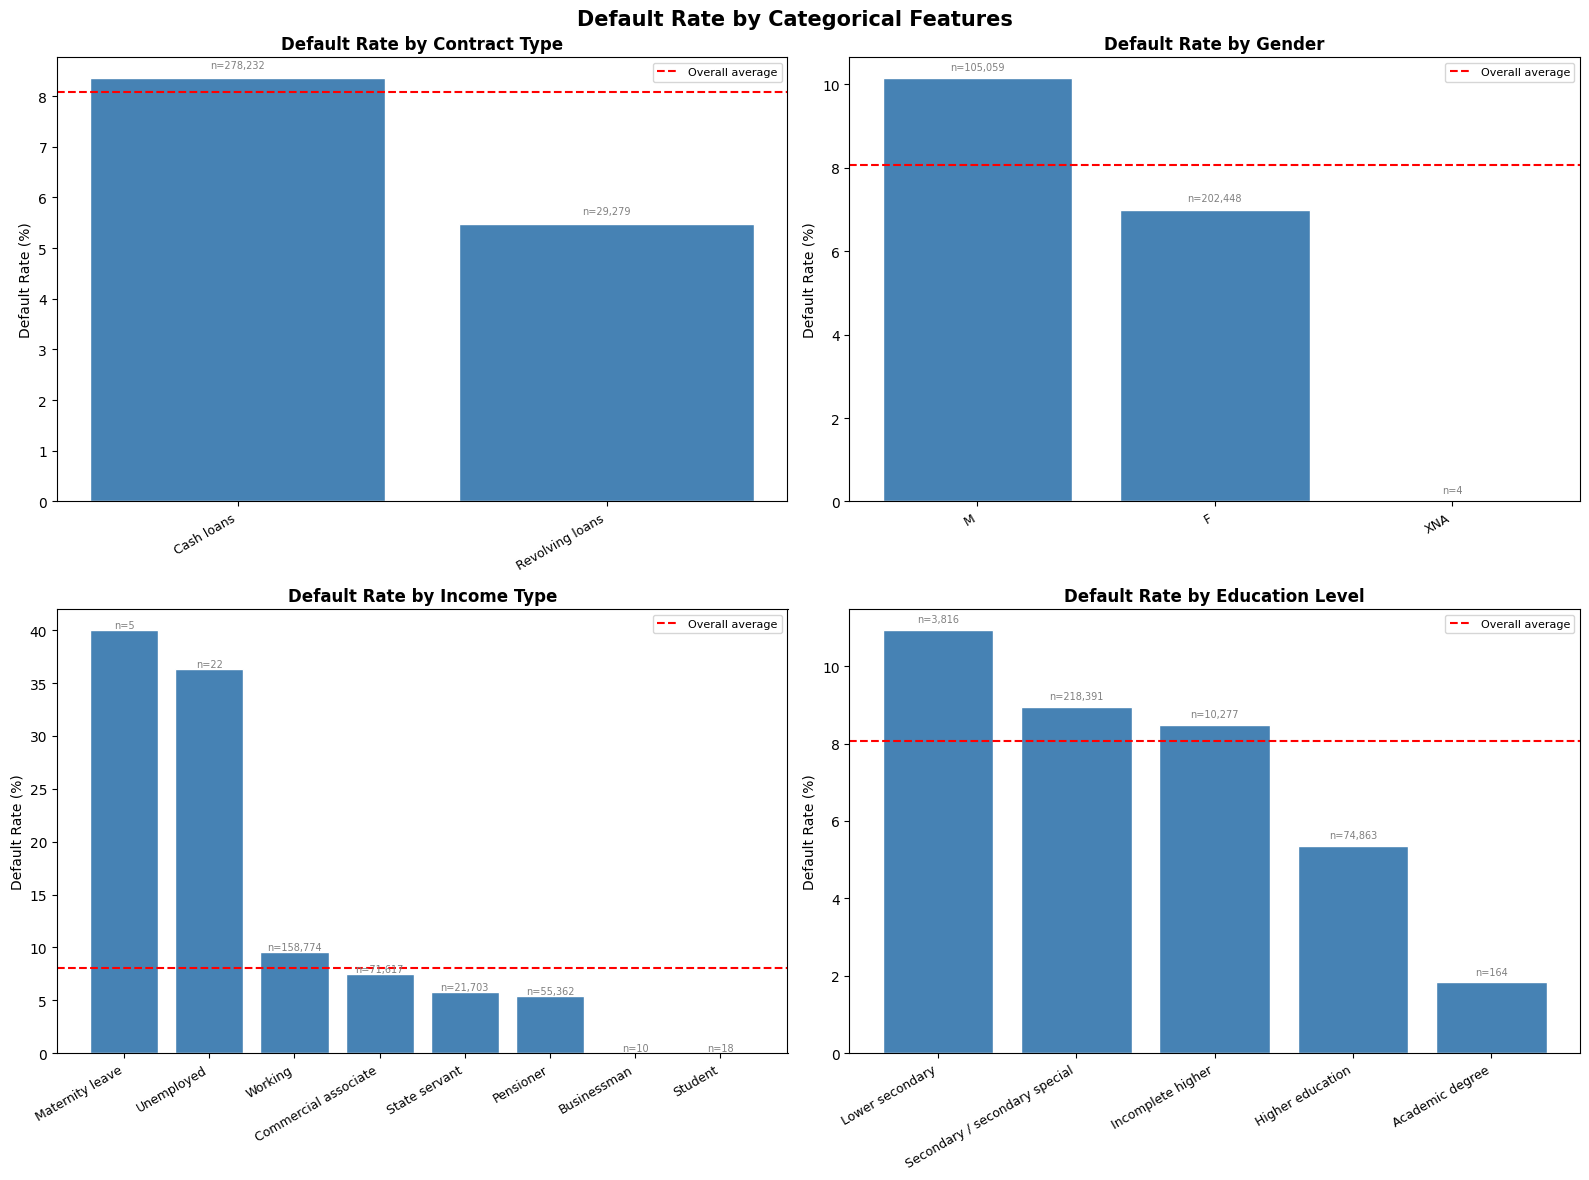

Visualisations 7 & 8 saved.


In [10]:
# Visualisations 7 & 8: Default rate by key categorical variables
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

categorical_vars = [
    ('NAME_CONTRACT_TYPE', 'Contract Type'),
    ('CODE_GENDER', 'Gender'),
    ('NAME_INCOME_TYPE', 'Income Type'),
    ('NAME_EDUCATION_TYPE', 'Education Level')
]

for ax, (col, title) in zip(axes.flatten(), categorical_vars):
    default_rate = app_train.groupby(col)['TARGET'].mean().sort_values(ascending=False)
    counts = app_train[col].value_counts()
    
    bars = ax.bar(range(len(default_rate)), 
                  default_rate.values * 100,
                  color='steelblue', edgecolor='white')
    
    ax.set_xticks(range(len(default_rate)))
    ax.set_xticklabels(default_rate.index, rotation=30, ha='right', fontsize=9)
    ax.set_title(f'Default Rate by {title}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Default Rate (%)')
    ax.axhline(y=app_train['TARGET'].mean() * 100, 
               color='red', linestyle='--', linewidth=1.5, label='Overall average')
    ax.legend(fontsize=8)
    
    # Add count labels on bars
    for i, (bar, idx) in enumerate(zip(bars, default_rate.index)):
        ax.text(bar.get_x() + bar.get_width()/2, 
                bar.get_height() + 0.2,
                f'n={counts[idx]:,}', 
                ha='center', fontsize=7, color='gray')

plt.suptitle('Default Rate by Categorical Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/default_rate_categorical.png', dpi=150)
plt.show()

print("Visualisations 7 & 8 saved.")

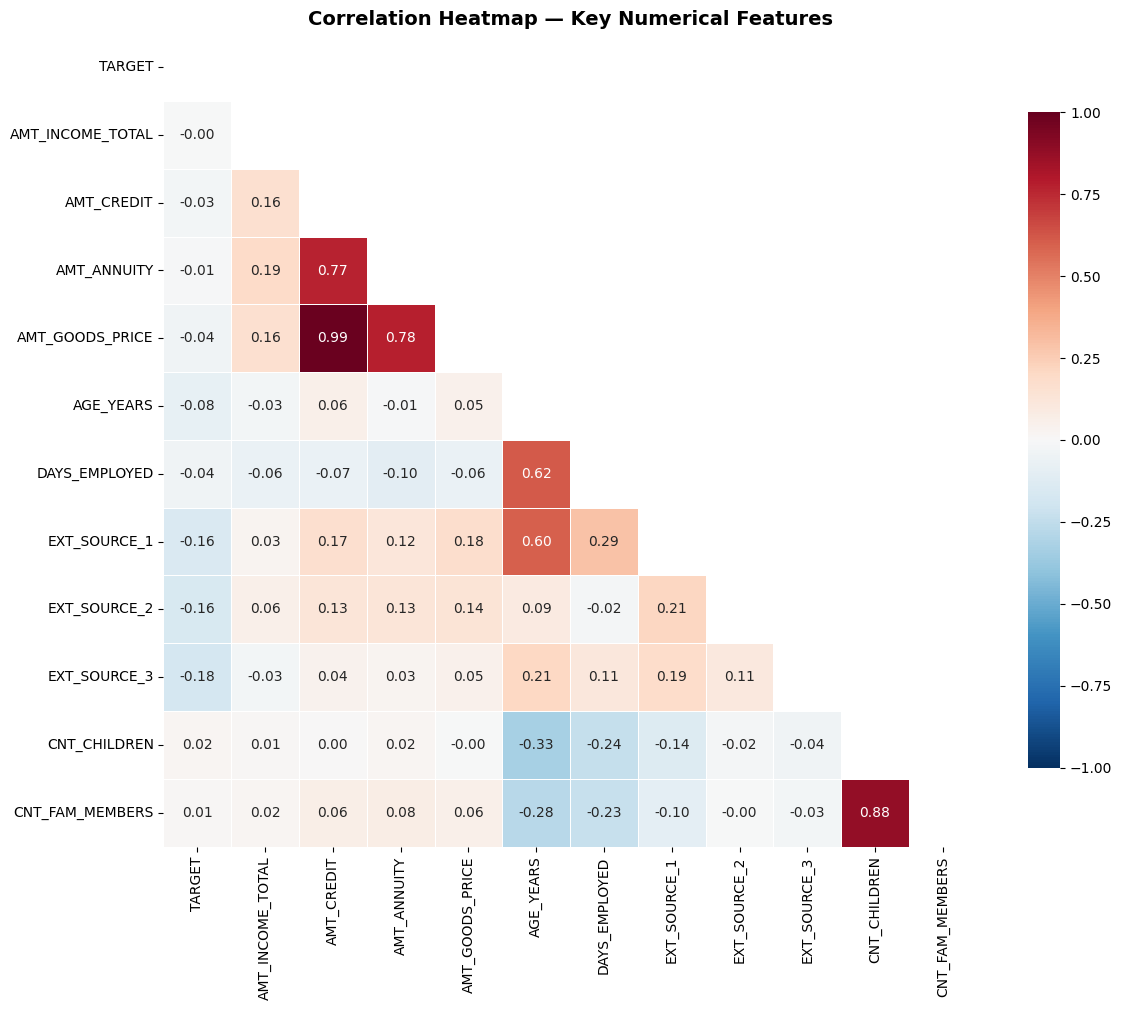

Visualisation 9 saved.


In [11]:
# Visualisation 9: Correlation heatmap
key_features = [
    'TARGET', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
    'AMT_GOODS_PRICE', 'AGE_YEARS', 'DAYS_EMPLOYED',
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'CNT_CHILDREN', 'CNT_FAM_MEMBERS'
]

corr_matrix = app_train[key_features].corr()

plt.figure(figsize=(12, 10))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr_matrix, 
            mask=mask,
            annot=True, 
            fmt='.2f', 
            cmap='RdBu_r',
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})

plt.title('Correlation Heatmap — Key Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/correlation_heatmap.png', dpi=150)
plt.show()

print("Visualisation 9 saved.")

EXT_SOURCE_1 — Median (No Default): 0.517 | Median (Default): 0.362
EXT_SOURCE_2 — Median (No Default): 0.574 | Median (Default): 0.440
EXT_SOURCE_3 — Median (No Default): 0.546 | Median (Default): 0.379


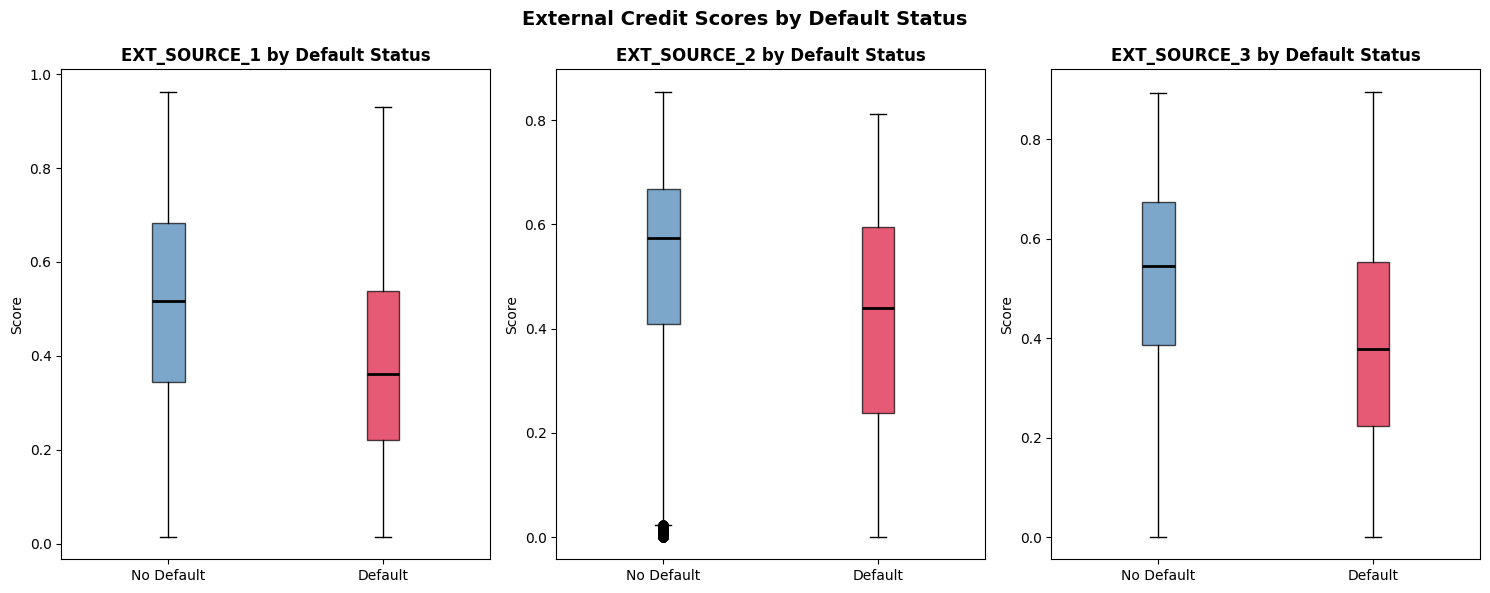


Visualisation 10 saved.


In [12]:
# Visualisation 10: EXT_SOURCE scores by default status (box plots)
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for i, col in enumerate(['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
    data_0 = app_train[app_train['TARGET'] == 0][col].dropna()
    data_1 = app_train[app_train['TARGET'] == 1][col].dropna()
    
    bp = axes[i].boxplot([data_0, data_1], 
                          labels=['No Default', 'Default'],
                          patch_artist=True,
                          medianprops={'color': 'black', 'linewidth': 2})
    
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor('crimson')
    bp['boxes'][1].set_alpha(0.7)
    
    axes[i].set_title(f'{col} by Default Status', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Score')
    
    # Print median values
    print(f"{col} — Median (No Default): {data_0.median():.3f} | Median (Default): {data_1.median():.3f}")

plt.suptitle('External Credit Scores by Default Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/ext_source_boxplots.png', dpi=150)
plt.show()

print("\nVisualisation 10 saved.")

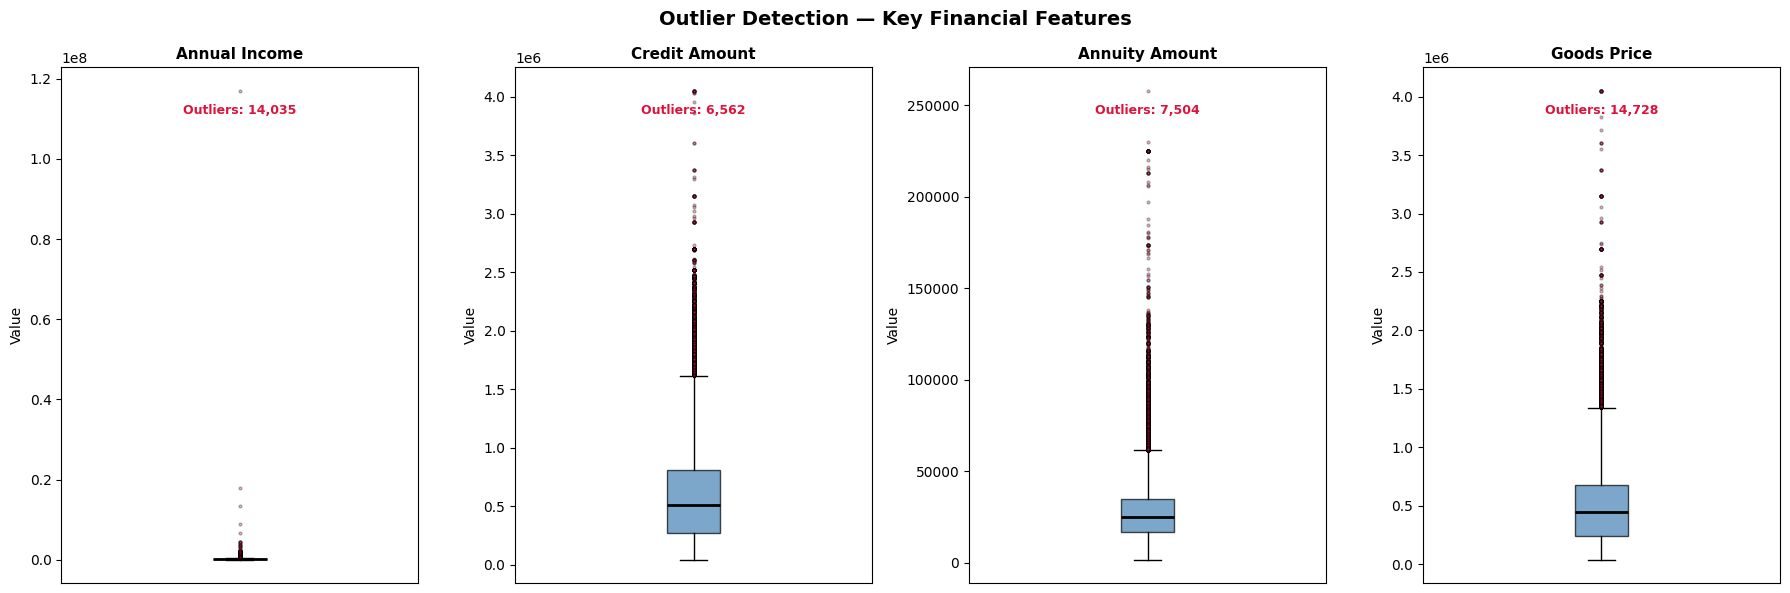

=== OUTLIER SUMMARY ===
Annual Income: 14,035 outliers (4.6%)
Credit Amount: 6,562 outliers (2.1%)
Annuity Amount: 7,504 outliers (2.4%)
Goods Price: 14,728 outliers (4.8%)


In [13]:
# Visualisation 11: Outlier detection using box plots
fig, axes = plt.subplots(1, 4, figsize=(18, 6))

financial_features = [
    ('AMT_INCOME_TOTAL', 'Annual Income'),
    ('AMT_CREDIT', 'Credit Amount'),
    ('AMT_ANNUITY', 'Annuity Amount'),
    ('AMT_GOODS_PRICE', 'Goods Price')
]

for ax, (col, title) in zip(axes, financial_features):
    data = app_train[col].dropna()
    
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    outlier_count = ((data < q1 - 1.5 * iqr) | (data > q3 + 1.5 * iqr)).sum()
    
    bp = ax.boxplot(data, patch_artist=True,
                    medianprops={'color': 'black', 'linewidth': 2},
                    flierprops={'marker': 'o', 'markersize': 2, 
                                'markerfacecolor': 'crimson', 'alpha': 0.3})
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][0].set_alpha(0.7)
    
    ax.set_title(f'{title}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Value')
    ax.set_xticks([])
    ax.text(1, data.max() * 0.95, f'Outliers: {outlier_count:,}',
            ha='center', fontsize=9, color='crimson', fontweight='bold')

plt.suptitle('Outlier Detection — Key Financial Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/outlier_detection.png', dpi=150)
plt.show()

# Print summary statistics
print("=== OUTLIER SUMMARY ===")
for col, title in financial_features:
    data = app_train[col].dropna()
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    outliers = ((data < q1 - 1.5 * iqr) | (data > q3 + 1.5 * iqr)).sum()
    print(f"{title}: {outliers:,} outliers ({outliers/len(data)*100:.1f}%)")

Credit-to-Income Ratio — No Default median: 3.267
Credit-to-Income Ratio — Default median: 3.253

Annuity Burden Ratio — No Default median: 0.162
Annuity Burden Ratio — Default median: 0.169



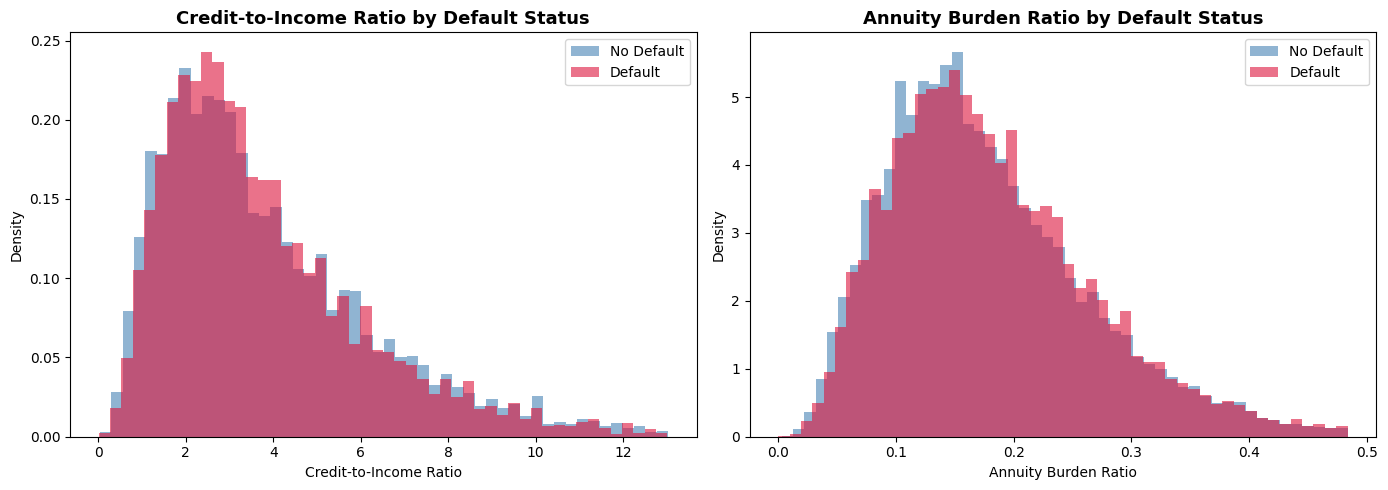

Visualisations 12 & 13 saved.


In [14]:
# Visualisation 12 & 13: Engineered ratio analysis
app_train['CREDIT_INCOME_RATIO'] = app_train['AMT_CREDIT'] / app_train['AMT_INCOME_TOTAL']
app_train['ANNUITY_INCOME_RATIO'] = app_train['AMT_ANNUITY'] / app_train['AMT_INCOME_TOTAL']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (col, title) in zip(axes, [
    ('CREDIT_INCOME_RATIO', 'Credit-to-Income Ratio'),
    ('ANNUITY_INCOME_RATIO', 'Annuity Burden Ratio')
]):
    cap = app_train[col].quantile(0.99)
    
    for target, label, color in [(0, 'No Default', 'steelblue'), (1, 'Default', 'crimson')]:
        subset = app_train[
            (app_train['TARGET'] == target) & 
            (app_train[col] <= cap)
        ][col]
        ax.hist(subset, bins=50, alpha=0.6, label=label, color=color, edgecolor='none', density=True)
    
    ax.set_title(f'{title} by Default Status', fontsize=13, fontweight='bold')
    ax.set_xlabel(title)
    ax.set_ylabel('Density')
    ax.legend()
    
    # Print group medians
    for target, label in [(0, 'No Default'), (1, 'Default')]:
        median = app_train[app_train['TARGET'] == target][col].median()
        print(f"{title} — {label} median: {median:.3f}")
    print()

plt.tight_layout()
plt.savefig('reports/ratio_analysis.png', dpi=150)
plt.show()

print("Visualisations 12 & 13 saved.")

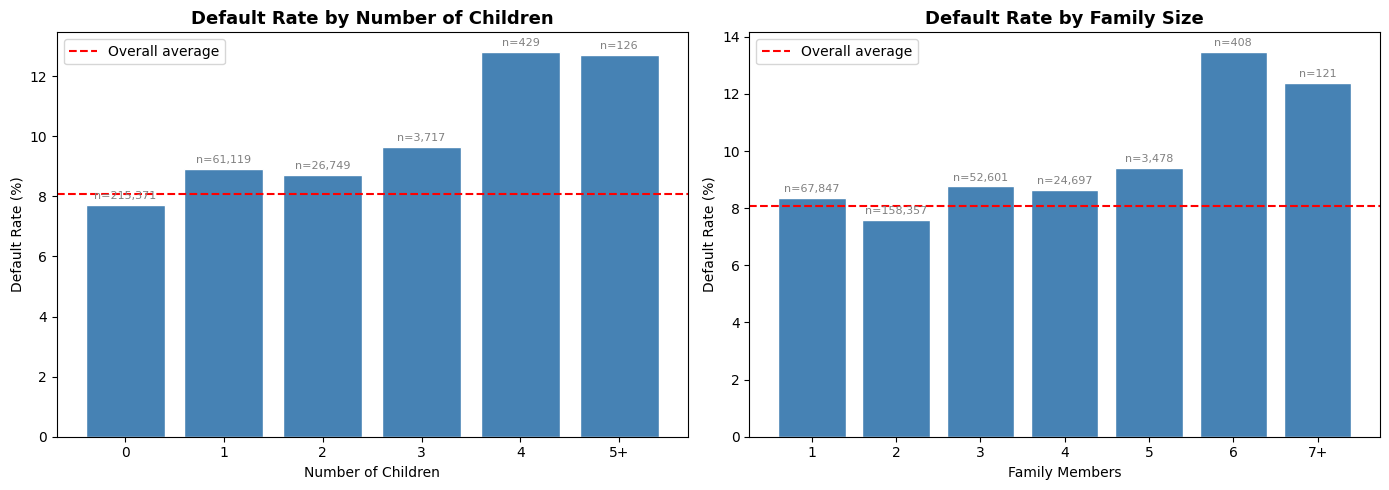

Visualisation 14 saved.


In [15]:
# Visualisation 14: Default rate by children and family size
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Children count — cap at 5+ to avoid tiny groups
app_train['CNT_CHILDREN_CAP'] = app_train['CNT_CHILDREN'].clip(upper=5)
children_default = app_train.groupby('CNT_CHILDREN_CAP')['TARGET'].agg(['mean', 'count'])
children_default.index = [str(int(i)) if i < 5 else '5+' for i in children_default.index]

axes[0].bar(children_default.index, 
            children_default['mean'] * 100,
            color='steelblue', edgecolor='white')
axes[0].axhline(y=app_train['TARGET'].mean() * 100, 
                color='red', linestyle='--', linewidth=1.5, label='Overall average')
for i, (idx, row) in enumerate(children_default.iterrows()):
    axes[0].text(i, row['mean'] * 100 + 0.2, 
                 f"n={int(row['count']):,}", 
                 ha='center', fontsize=8, color='gray')
axes[0].set_title('Default Rate by Number of Children', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Children')
axes[0].set_ylabel('Default Rate (%)')
axes[0].legend()

# Family size
app_train['CNT_FAM_CAP'] = app_train['CNT_FAM_MEMBERS'].clip(upper=7)
fam_default = app_train.groupby('CNT_FAM_CAP')['TARGET'].agg(['mean', 'count'])
fam_default.index = [str(int(i)) if i < 7 else '7+' for i in fam_default.index]

axes[1].bar(fam_default.index,
            fam_default['mean'] * 100,
            color='steelblue', edgecolor='white')
axes[1].axhline(y=app_train['TARGET'].mean() * 100,
                color='red', linestyle='--', linewidth=1.5, label='Overall average')
for i, (idx, row) in enumerate(fam_default.iterrows()):
    axes[1].text(i, row['mean'] * 100 + 0.2,
                 f"n={int(row['count']):,}",
                 ha='center', fontsize=8, color='gray')
axes[1].set_title('Default Rate by Family Size', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Family Members')
axes[1].set_ylabel('Default Rate (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('reports/children_family_default.png', dpi=150)
plt.show()

print("Visualisation 14 saved.")

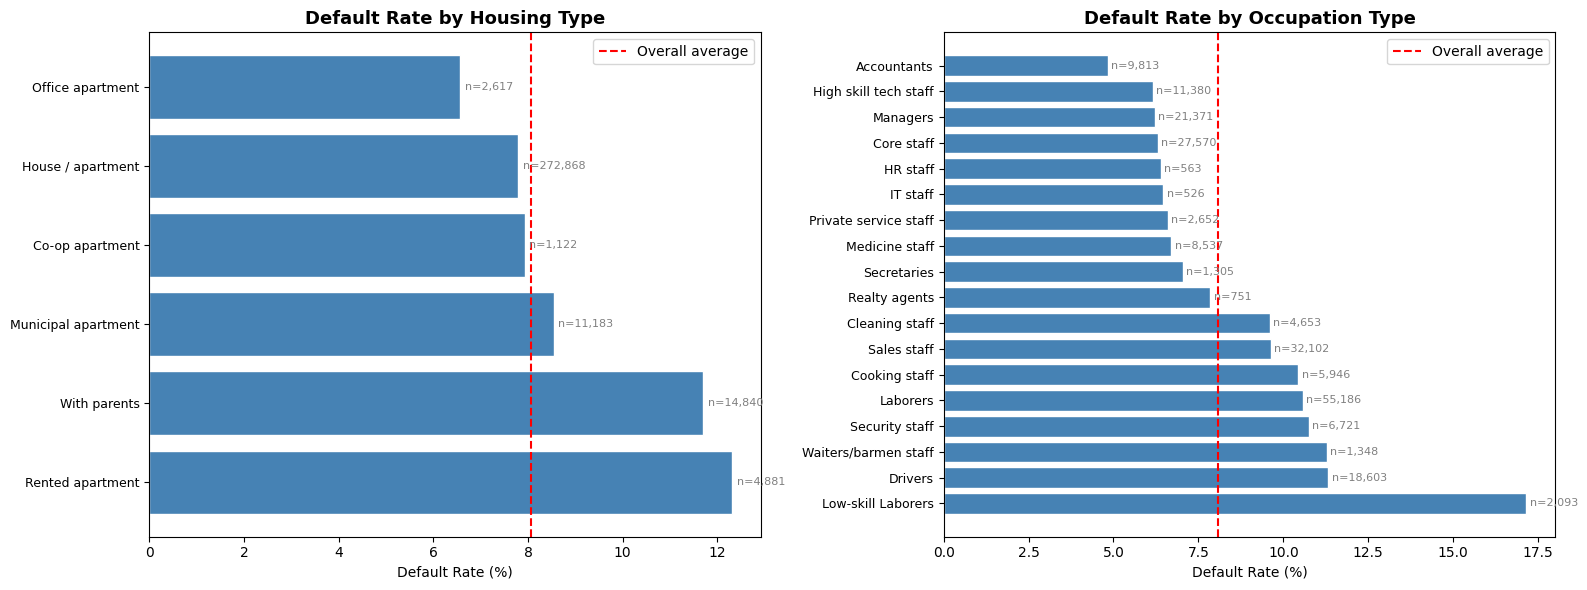

Visualisation 15 saved.

=== VISUALISATION TRACKER ===
  ✓ 1. Missing values bar chart
  ✓ 2. Target distribution — count and pie
  ✓ 3. Income distribution by default status
  ✓ 4. Credit amount distribution by default status
  ✓ 5. Age distribution by default status
  ✓ 6. Employment length by default status
  ✓ 7-10. Default rate by contract type, gender, income type, education
  ✓ 9. Correlation heatmap
  ✓ 10. EXT_SOURCE box plots
  ✓ 11. Outlier detection — financial features
  ✓ 12. Credit-to-income ratio distribution
  ✓ 13. Annuity burden ratio distribution
  ✓ 14. Default rate by children and family size
  ✓ 15. Default rate by housing and occupation type

Minimum requirement (15): MET


In [17]:
# Visualisation 15: Default rate by housing type and occupation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Housing type
housing_default = app_train.groupby('NAME_HOUSING_TYPE')['TARGET'].agg(['mean', 'count'])
housing_default = housing_default.sort_values('mean', ascending=False)

axes[0].barh(range(len(housing_default)), 
             housing_default['mean'] * 100,
             color='steelblue', edgecolor='white')
axes[0].set_yticks(range(len(housing_default)))
axes[0].set_yticklabels(housing_default.index, fontsize=9)
axes[0].axvline(x=app_train['TARGET'].mean() * 100,
                color='red', linestyle='--', linewidth=1.5, label='Overall average')
for i, (idx, row) in enumerate(housing_default.iterrows()):
    axes[0].text(row['mean'] * 100 + 0.1, i,
                 f"n={int(row['count']):,}", va='center', fontsize=8, color='gray')
axes[0].set_title('Default Rate by Housing Type', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Default Rate (%)')
axes[0].legend()

# Occupation type
occ_default = app_train.groupby('OCCUPATION_TYPE')['TARGET'].agg(['mean', 'count'])
occ_default = occ_default[occ_default['count'] >= 500]
occ_default = occ_default.sort_values('mean', ascending=False)

axes[1].barh(range(len(occ_default)),
             occ_default['mean'] * 100,
             color='steelblue', edgecolor='white')
axes[1].set_yticks(range(len(occ_default)))
axes[1].set_yticklabels(occ_default.index, fontsize=9)
axes[1].axvline(x=app_train['TARGET'].mean() * 100,
                color='red', linestyle='--', linewidth=1.5, label='Overall average')
for i, (idx, row) in enumerate(occ_default.iterrows()):
    axes[1].text(row['mean'] * 100 + 0.1, i,
                 f"n={int(row['count']):,}", va='center', fontsize=8, color='gray')
axes[1].set_title('Default Rate by Occupation Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Default Rate (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('reports/housing_occupation_default.png', dpi=150)
plt.show()

print("Visualisation 15 saved.")
print(f"\n=== VISUALISATION TRACKER ===")
visuals = [
    "1. Missing values bar chart",
    "2. Target distribution — count and pie",
    "3. Income distribution by default status",
    "4. Credit amount distribution by default status",
    "5. Age distribution by default status",
    "6. Employment length by default status",
    "7-10. Default rate by contract type, gender, income type, education",
    "9. Correlation heatmap",
    "10. EXT_SOURCE box plots",
    "11. Outlier detection — financial features",
    "12. Credit-to-income ratio distribution",
    "13. Annuity burden ratio distribution",
    "14. Default rate by children and family size",
    "15. Default rate by housing and occupation type"
]
for v in visuals:
    print(f"  ✓ {v}")
print(f"\nMinimum requirement (15): MET")

In [18]:
# Save EDA summary statistics
summary = app_train.describe().T
summary.to_csv("reports/eda_summary_statistics.csv")
print("Summary statistics saved to reports/eda_summary_statistics.csv")
print("\n=== STEP 2 COMPLETE ===")
print("EDA Notebook: DONE")
print("Visualisations: 15 of 15 minimum COMPLETE")
print("Insights Summary: PENDING")

Summary statistics saved to reports/eda_summary_statistics.csv

=== STEP 2 COMPLETE ===
EDA Notebook: DONE
Visualisations: 15 of 15 minimum COMPLETE
Insights Summary: PENDING
